In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [28]:
df = sns.load_dataset("titanic")

df.drop('deck', inplace=True, axis=1)

imputer = SimpleImputer(strategy='median')
df[['age', 'fare']] = imputer.fit_transform(df[['age', 'fare']])

imputer = SimpleImputer(strategy='most_frequent')
df[['embarked', 'embark_town']] = imputer.fit_transform(df[['embarked', 'embark_town']])

df.isnull().sum().sort_values(ascending=False)

le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = le.fit_transform(df[col])
    
X = df.drop(['survived', 'alive'], axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=2)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.96      0.83       105
           1       0.90      0.51      0.66        74

    accuracy                           0.78       179
   macro avg       0.82      0.74      0.74       179
weighted avg       0.81      0.78      0.76       179



<Axes: >

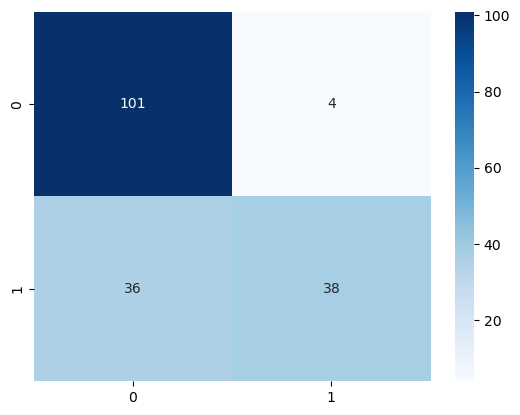

In [29]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

In [30]:
from sklearn.tree import export_graphviz

export_graphviz(model, out_file='./saved_models/decision_tree.dot', feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)